In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

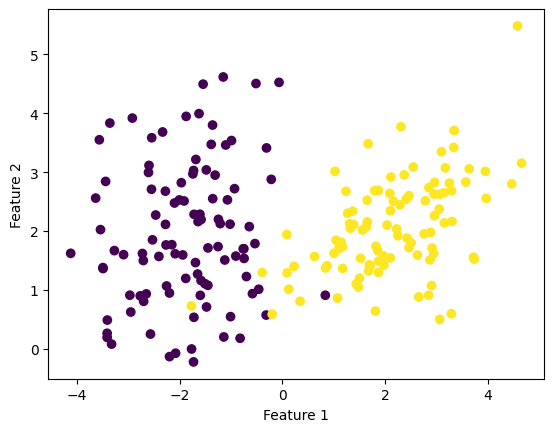

In [11]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=1,
    class_sep=2,
    random_state=42
)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [14]:
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

# Xavier/Glorat Init

In [15]:
model = Sequential()

model.add(Dense(10,activation='tanh',input_dim=2))
model.add(Dense(10,activation='tanh'))
model.add(Dense(10,activation='tanh'))
model.add(Dense(10,activation='tanh'))
model.add(Dense(1,activation='sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
initial_weights = model.get_weights()

In [18]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [19]:
model.set_weights(initial_weights)

In [20]:
model.get_weights()

[array([[-0.28410828, -1.109384  ,  0.04478395,  0.22711752,  0.4670183 ,
          0.7667743 , -0.52389926, -0.8009242 ,  0.10554027,  0.2298384 ],
        [-0.22176176,  0.78763604, -1.0273542 , -0.98046327,  0.56542397,
          0.31715086, -0.19343527,  0.8194338 ,  0.50432116, -0.386444  ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.09846644, -0.27872378, -0.21226497,  0.74846625, -0.24333932,
         -0.06902545, -0.5551223 , -0.14765939, -0.47282374, -0.785626  ],
        [ 0.31466517, -0.41920364, -0.43551046, -0.7766897 ,  0.2037175 ,
          0.07885697,  0.00139622,  0.04277782, -0.16414325, -0.28781414],
        [-0.31008536,  0.45070338, -0.0473369 ,  0.5260917 ,  0.15562953,
         -0.05970431,  0.00442559,  0.2244674 , -0.22247939,  0.41189972],
        [-0.27774554, -0.01771924, -0.13818017,  0.31971928, -0.03538417,
          0.831668  , -0.66690266, -0.37467346, -0.05895372,  0.04204384],
        [ 0.03803

In [21]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [22]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.5314 - loss: 0.8373 - val_accuracy: 0.4500 - val_loss: 0.8300
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4975 - loss: 0.7944 - val_accuracy: 0.5000 - val_loss: 0.7395
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5503 - loss: 0.6801 - val_accuracy: 0.5000 - val_loss: 0.6581
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5607 - loss: 0.6161 - val_accuracy: 0.6250 - val_loss: 0.5861
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6625 - loss: 0.5602 - val_accuracy: 0.9250 - val_loss: 0.5238
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9306 - loss: 0.5137 - val_accuracy: 1.0000 - val_loss: 0.4736
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9478 - loss: 0.4592 - val_accuracy: 0.9500 - val_loss: 0.4320
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9507 - loss: 0.4232 - val_accuracy: 0.9250 - val_loss:

In [23]:
model.get_weights()

[array([[-0.23161104, -1.2300502 , -0.02559035,  0.3005167 ,  0.5990302 ,
          0.9943523 , -0.692471  , -0.75426745,  0.10536862,  0.16140547],
        [-0.13868041,  0.4924583 , -1.1679492 , -0.80508274,  0.4724204 ,
          0.09403117, -0.03939262,  0.8909214 ,  0.6349811 , -0.48922166]],
       dtype=float32),
 array([ 0.04603149, -0.27943504, -0.06843981,  0.16249128,  0.01218596,
         0.00985761, -0.09172928,  0.07560971,  0.1503802 , -0.12233637],
       dtype=float32),
 array([[-0.05908949, -0.1776029 , -0.2698215 ,  0.6509522 , -0.16737416,
         -0.12133539, -0.48471463, -0.08336528, -0.5176989 , -0.73322564],
        [ 0.46105814, -0.30022383, -0.58659077, -0.81764996,  0.2558154 ,
         -0.02901908,  0.10403519,  0.14078647, -0.2681049 , -0.19853327],
        [-0.20984614,  0.40726438, -0.083434  ,  0.3387072 ,  0.25427425,
         -0.12386765,  0.08872234,  0.3286422 , -0.25433815,  0.43716994],
        [-0.21998374, -0.08322367, -0.13211368,  0.13521297, 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


<Axes: >

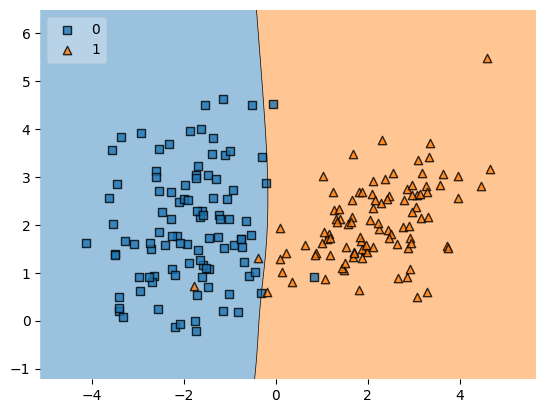

In [24]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

# Relu  - HE normal

In [25]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
initial_weights = model.get_weights()

In [27]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(2/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(2/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(2/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(2/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(2/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [28]:
model.set_weights(initial_weights)

In [29]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [30]:
history2 = model.fit(X,y,epochs =100,validation_split=0.2)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.4876 - loss: 0.5376 - val_accuracy: 0.5250 - val_loss: 0.5382
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8010 - loss: 0.4934 - val_accuracy: 1.0000 - val_loss: 0.5064
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9762 - loss: 0.4527 - val_accuracy: 1.0000 - val_loss: 0.4808
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9665 - loss: 0.4358 - val_accuracy: 1.0000 - val_loss: 0.4565
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9682 - loss: 0.4134 - val_accuracy: 1.0000 - val_loss: 0.4299
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9721 - loss: 0.3885 - val_accuracy: 1.0000 - val_loss: 0.4025
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9691 - loss: 0.3762 - val_accuracy: 1.0000 - val_loss: 0.3775
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9760 - loss: 0.3464 - val_accuracy: 1.0000 - val_loss:

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

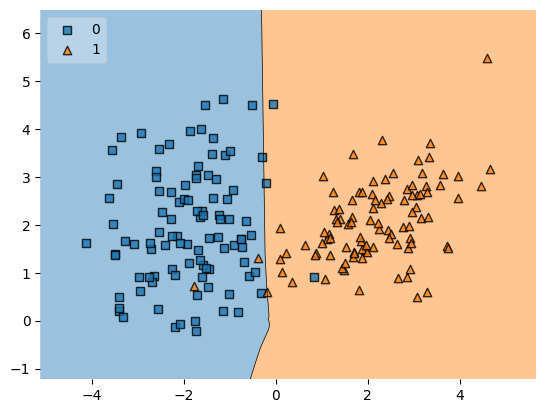

In [31]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

# Using Keras

In [32]:
model = Sequential()
# kernel_initializer='he_normal' , 'glorot_normal','glorot_uniform', 'he_uniform'
model.add(Dense(10,activation='relu',input_dim=2,kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(1,activation='sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [34]:
hist3 = model.fit(X,y,epochs =100,validation_split=0.2,verbose = False)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


<Axes: >

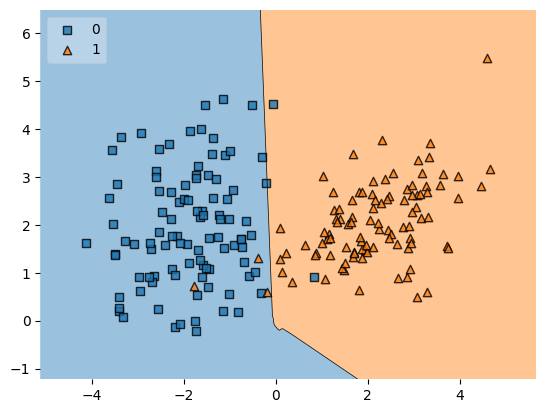

In [35]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)